<a href="https://colab.research.google.com/github/Harsh-Sama/MANIT-Submissions/blob/main/GMM(Assignment_4_GenAI).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

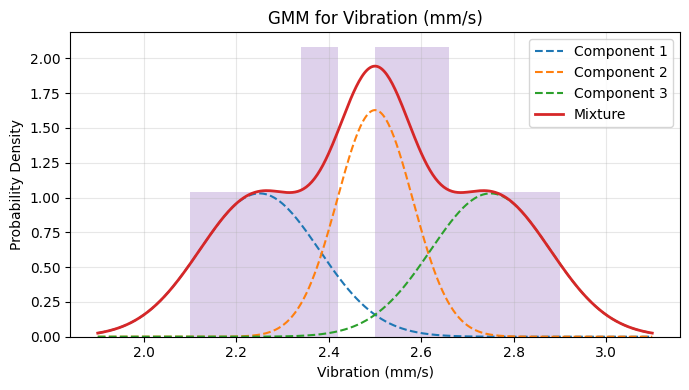

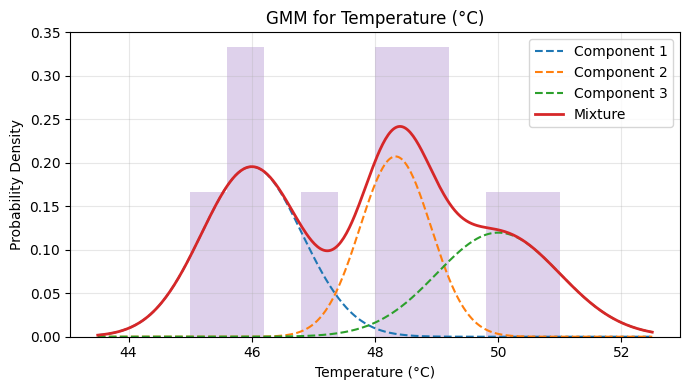

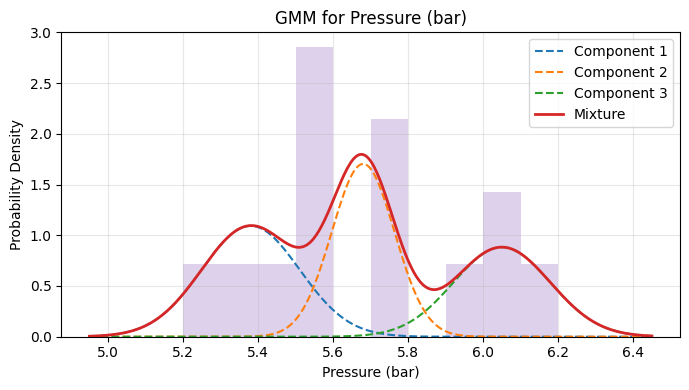

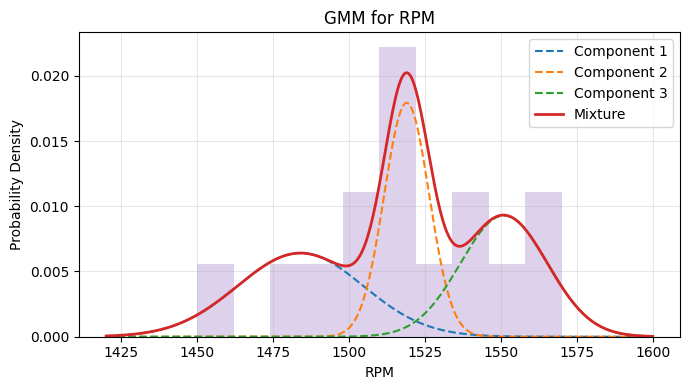

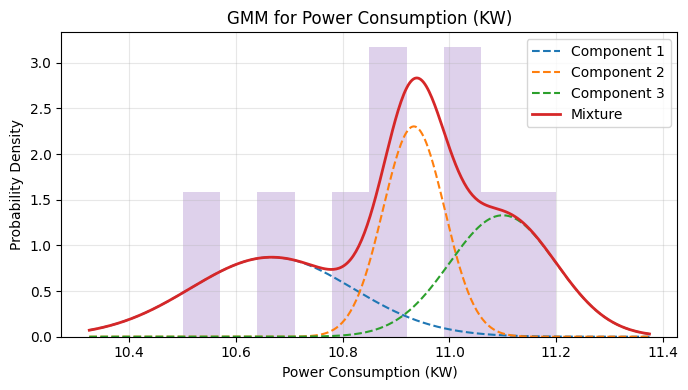

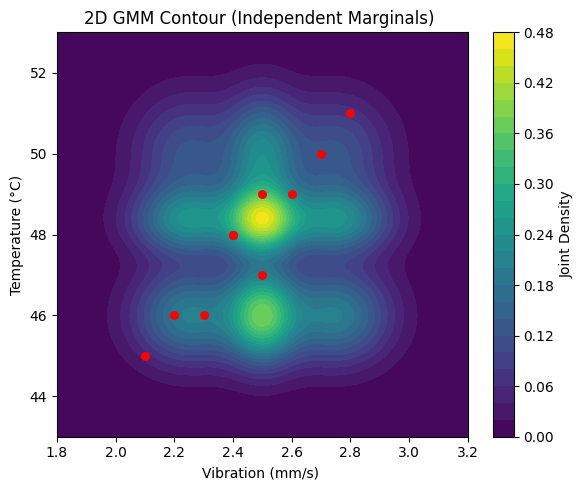

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Gaussian PDF (1D)
def gaussian_1d(x, mu, var):
	return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-(x - mu) ** 2 / (2 * var))

#Safe variance to avoid collapse
def safe_variance (x, min_frac=0.05) :
	"""
	x: 1D data
	min_frac : minimum variance as fraction of data range
	"""
	if len (x) <= 1:
		return 1.0
	data_var = np.var (x, ddof=1)
	data_range = np.max (x) - np.min (x)
	min_var = (min_frac * data_range) ** 2
	return max (data_var, min_var)

# Simple 1D GMM initialization
def gmm_1d (data, K=2):
	data = data[~np.isnan(data)]
	data = np.sort(data)
	splits = np. array_split(data, K)
	mus, vars_, pis = [], [], []
	N = len(data)

	for s in splits:
		mus.append (np.mean(s))
		vars_.append(safe_variance(s))
		pis.append(len(s)/N)
	return mus, vars_, pis

# Train GMM for each feature
def gmm_model (X, k=2):
	gmm_models = []
	for i in range (X.shape [0]) :
		mus, vars_, pis = gmm_1d(X[i], k)
		gmm_models.append( (mus, vars_, pis))
	return gmm_models

# GMM PDF
def gmm_1d_pdf(x, mus, vars_,pis):
	pdf = np.zeros_like(x, dtype=float)
	for mu, var, pi in zip (mus, vars_, pis):
		pdf += pi * gaussian_1d (x, mu, var)
	return pdf

#MACHINE SENSOR DATA (CHANGED EXAMPLE)
x = np.array([
	# Vibration (mm/s)
	[2.1, 2.3, 2.5, 2.4, 2.2, 2.6, 2.7, 2.8, 2.5, 2.4, 2.6, 2.9,
	np.nan, np.nan, np.nan],

	# Temperature (degree celsius)
	[45, 46, 47, 48, 46, 49, 50, 51, 49, 48,
	np.nan, np.nan, np.nan, np.nan, np.nan],

	# Pressure (bar)
	[5.2, 5.3, 5.5, 5.6, 5.4, 5.7, 5.8, 5.9, 5.6, 5.5, 5.7, 6.0, 6.1, 6.2, np.nan],

	# RPM
	[1450, 1480, 1500, 1520, 1490, 1510, 1530, 1540, 1550, 1520, 1500, 1515, 1535, 1560, 1570],

	# Power Consumption (kW)
	[10.5, 10.7, 10.9, 11.0, 10.8, 11.1, 11.2, 11.0, 10.9, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
	])

labels = [
"Vibration (mm/s)",
"Temperature (°C)",
"Pressure (bar)",
"RPM",
"Power Consumption (KW)"
]

# Train GMMS
gmm_models = gmm_model(x, k=3)

# 1D GMM VISUALIZATION
for i, label in enumerate (labels) :
	data = x[i][~np.isnan(x[i])]
	mus, vars_, pis = gmm_models[i]

	x_vals = np.linspace(
		data.min () - 0.25 * np.ptp (data),
		data.max () + 0.25 * np.ptp (data),
		400
	)
	plt.figure(figsize=(7, 4))

	mixture = np.zeros_like (x_vals)

	for k in range (len (mus)) :
		comp = pis [k] * gaussian_1d (x_vals, mus [k], vars_[k])
		mixture += comp
		plt.plot(x_vals, comp, '--', label=f'Component {k + 1}')

	plt.plot (x_vals, mixture, linewidth=2, label='Mixture')
	plt.hist (data, bins=10, density=True, alpha=0.3)
	plt.title (f"GMM for {label}")
	plt.xlabel (label)
	plt.ylabel ("Probability Density")
	plt. legend ()
	plt.grid(alpha=0.3)
	plt. tight_layout ()
	plt. show ()

# 2D JOINT DENSITY (INDEPENDENT MARGINALS)
i, j = 0, 1 # Vibration vs Temperature

mus_x, vars_x, pis_x = gmm_models [i]
mus_y, vars_y, pis_y= gmm_models [j]

x_2d = np.linspace(1.8, 3.2, 200)
y_2d = np.linspace (43, 53, 200)

Xg, Yg = np.meshgrid(x_2d, y_2d)

Px = gmm_1d_pdf(x_2d, mus_x, vars_x, pis_x)

Py = gmm_1d_pdf(y_2d, mus_y, vars_y, pis_y)
Z = np.outer (Py, Px)

plt.figure(figsize= (6, 5))
plt.contourf(Xg, Yg, Z, levels=30, cmap="viridis")
plt.colorbar (label="Joint Density")

# Get the mask for non-NaN values for feature i
valid_i_mask = ~np.isnan(x[i])
# Get the mask for non-NaN values for feature j
valid_j_mask = ~np.isnan(x[j])
# Combine masks to find indices where both are valid
combined_valid_mask = valid_i_mask & valid_j_mask

plt.scatter(
    x[i][combined_valid_mask],
    x[j][combined_valid_mask],
    c="red", s=30
)
plt.xlabel ("Vibration (mm/s) ")
plt. ylabel ("Temperature (°C)")
plt.title("2D GMM Contour (Independent Marginals) ")
plt.tight_layout ()
plt.show()